# Image processing, pt 1

## Libraries

Libraries are packages of code that people have written, and can be loaded. 

We'll be using code for plotting, importing files, and image analysis.

In [1]:
# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns
# Library to load tiff files
import tifffile as tiff
# General math libraries
import numpy as np
from scipy import stats
# Image analysis libraries/modules
import skimage as sk
from scipy import ndimage

# Segmentation and thresholding

A computer doesn't "know" what biological features are, unless we explicitly program it. For example, if we want to analyze cells, we'll need to be able to create a computer program that first of all knows which of the pixel of an image belong to a (single) cell.

Creating such regions of interest (ROIs) in an image is called segmentation.

## Case 1: segmenting an image with bimodal intensity profile


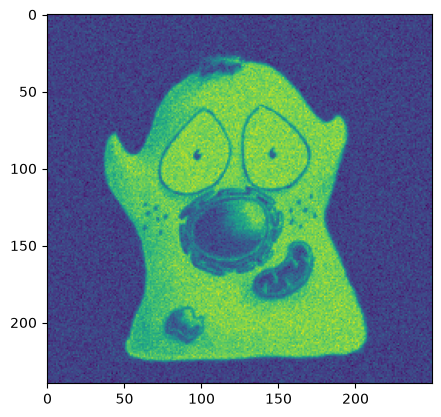

In [2]:
# Load the image using tiff library
img_happycell = tiff.imread("images/happy_cell_noise.tif")

_ = plt.imshow(img_happycell)

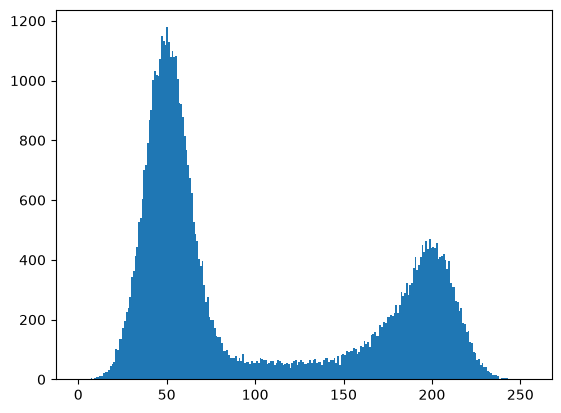

In [3]:
# Show the histogram
_ = plt.hist(img_happycell.ravel(), bins=256)

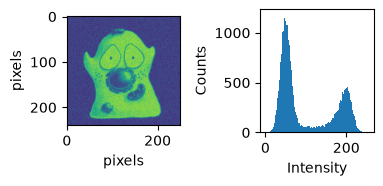

In [4]:


# Create a figure to display the image and it's histogram
fig, axs = plt.subplots(1,2, figsize=(10/2.54, 5/2.54))
_ = axs[0].imshow(img_happycell)
_ = axs[0].set_xlabel("pixels")
_ = axs[0].set_ylabel("pixels")
_ = axs[1].hist(img_happycell.ravel(), bins=256)
_ = axs[1].set_xlabel("Intensity")
_ = axs[1].set_ylabel("Counts")
_ = plt.tight_layout()

The intensity distribution of this image is called "bimodal", since it has two peaks.

#### Intermezzo: using functions

In [5]:
# To avoid re-writing code, create a function that does the same
def plot_img_and_hist(img):
    
    """Create a figure to display the image and it's histogram"""
    
    fig, axs = plt.subplots(1,2, figsize=(15/2.54, 5/2.54))
    # Plot image
    _ = axs[0].imshow(img)
    _ = axs[0].set_xlabel("pixels")
    _ = axs[0].set_ylabel("pixels")
    # Plot histogram
    _ = axs[1].hist(img.ravel(), bins=256)
    _ = axs[1].set_xlabel("Intensity")
    _ = axs[1].set_ylabel("Counts")
    _ = plt.tight_layout()

    return fig, axs

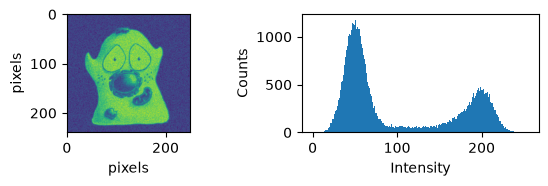

In [6]:
# And now call that function to test it
_, _ = plot_img_and_hist(img_happycell)

In [7]:
# A function is a piece of code that you can run by 
# typing the function name.
# It has inputs (arguments), and an output (return value).

# Function definition, the arguments, which you 
# can freely name, are between round brackets
def add_ab(a, b):
    # Documentation can go between three quotes.
    """ Return the sum of a and b. """

    # Some code
    c = a + b

    # Say what should be returned
    return c

# Now the function can be "called" by it's name, and it 
# will "return" the chosen values.
add_ab(2, 5)

7

***Source materials:** img_happycell is taken from [biobook](https://bioimagebook.github.io/chapters/2-processing/3-thresholding/thresholding.html) (fig. 68), [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).*

#### The segmentation

One algorithm that works well on bimodal distributions is Otsu's method. It will try to find a threshold
that minimizes the variance in the intensities that respectively fall above
and below that threshold. 
(For more info, see [biobook](https://bioimagebook.github.io/chapters/2-processing/3-thresholding/thresholding.html).)

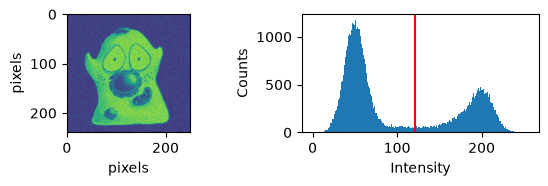

In [8]:
# Call the function to determine the otsu threshold from scikit image
thresh_otsu = sk.filters.threshold_otsu(img_happycell)
# Plot the result
fig, axs = plot_img_and_hist(img_happycell)
_ = axs[1].axvline(thresh_otsu, color="red")

In [9]:
# We can create a "mask", a binary image that represent 
# foreground and background
mask_happycell = img_happycell>thresh_otsu
# Inspecting what we did
mask_happycell[50:100, 50:100]

array([[False, False, False, ...,  True,  True,  True],
       [False, False, False, ...,  True,  True,  True],
       [False, False, False, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]], shape=(50, 50))

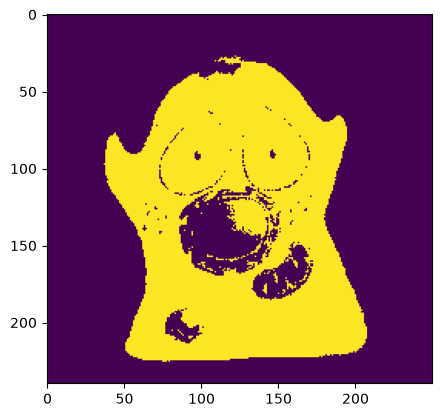

In [10]:
_ = plt.imshow(mask_happycell)

## Case 2: segmenting an image with a dominant background

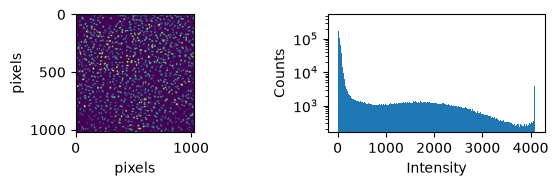

In [11]:
# Load image with kinase translocation reporter data
# Channel 0 are nuclei
img_nuclei = tiff.imread("images/KTR_t0.tif")[0,:,:]

# display
fig, axs = plot_img_and_hist(img_nuclei)
axs[1].set_yscale("log") # (not everyone likes this)

As can be seen, this image doesn't have a bimodal distribution, intead, it has a very strong background peak, and a relatively small number of pixels with higher intensity.

In this image, we'll aim to identify pixels that are above the dominant background peak.

#### Methodology

A method that's suitable for the "dominant background" case is the "triangle
method", which was published already by [Zack et al.](https://doi.org/10.1177/25.7.7045) in 1977.

<img src="figures/triangle_method.png" alt="The triangle method." height=400px>

In the figure above (from [Zack et al.](https://doi.org/10.1177/25.7.7045)), the method is 
explained. A line is drawn in the histogram between $x_\text{mode}, y(x_\text{mode})$ and
$x_\text{max}, 0$. Then, a second line is drawn, perpendicular to the first line,
which maximizes the distance to the histogram line. The x-value where that second line
touches the histogram, will be the threshold. (Originally, a margin of 0.2 was
included, but modern implementations leave that out.)


np.int64(121)

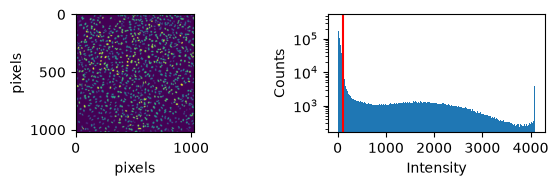

In [12]:
# Apply the triangle method
thresh_triangle = sk.filters.threshold_triangle(img_nuclei)
mask_nuclei = img_nuclei > thresh_triangle

fig, axs = plot_img_and_hist(img_nuclei)
axs[1].axvline(thresh_otsu, color="red")
axs[1].set_yscale("log")
thresh_otsu



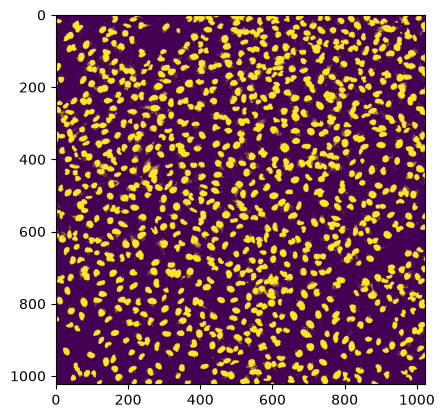

In [13]:
plt.imshow(mask_nuclei)

#### More thresholding-finding algorithms

More thresholding-finding algorithms exits. 
Threshold methods included in `skimage.filters` are:

```
threshold_isodata()
threshold_li()
threshold_mean()
threshold_minimum()
threshold_multiotsu()
threshold_niblack()
threshold_otsu()
threshold_sauvola()
threshold_triangle()
threshold_yen()
```

## Local thresholding

What we've seen so far are single threshold values that we apply to the whole image, ie "globally".
These are therefor global thresholds.

Let's look at an example where this goes wrong.

(<Figure size 590.551x196.85 with 2 Axes>,
 array([<Axes: xlabel='pixels', ylabel='pixels'>,
        <Axes: xlabel='Intensity', ylabel='Counts'>], dtype=object))

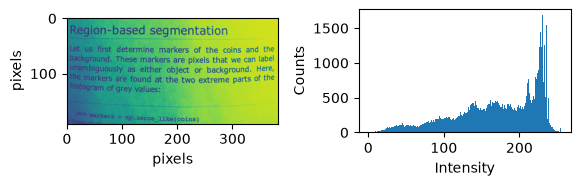

In [14]:
# Another example image
img_page = tiff.imread("images/page_original.tif")
plot_img_and_hist(img_page)

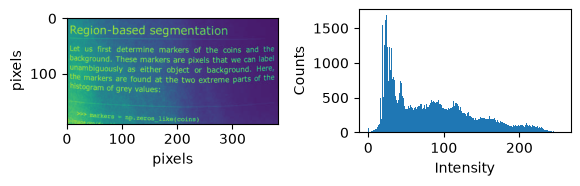

In [15]:
# When text is foreground, invert the image
img_page_inverted = np.invert(img_page)
_, _ = plot_img_and_hist(img_page_inverted)

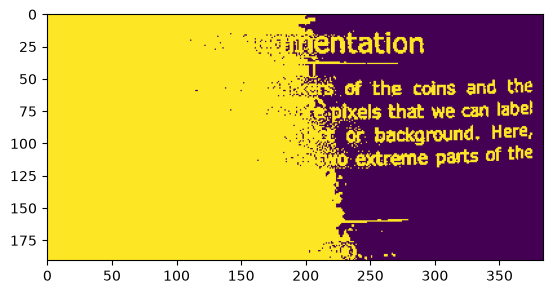

In [16]:
# Apply triangle
threshold_page1 = sk.filters.threshold_triangle(img_page_inverted)
mask_triangle = img_page_inverted > threshold_page1
_ = plt.imshow(mask_triangle)


However, if we inspect parts of the image separately, we might be able to find thresholds that can be applied locally that do separate back- and foreground.

In [17]:
# Find local threshold, i.e. for each pixel separately
# This will thus generate an array of size equal to the image
thresh_local = \
    sk.filters.threshold_local(
        img_page_inverted, 
        block_size=35, # check a "neighborhood" of 35x35 around each pixel
        offset=-10 # adjust the per-pixel thresholds globally by subtracting this number
    )

# Inspect shape (two methods)
print(np.shape(thresh_local))
print(thresh_local.shape)
# Show the result
print(thresh_local[1:10,1:10])


(191, 384)
(191, 384)
[[130.77211822 130.90207039 131.08406619 131.3037651  131.54411986
  131.78670404 132.01305378 132.20621863 132.35203808]
 [131.05212856 131.19449961 131.39410716 131.63543722 131.89996679
  132.16758333 132.41804769 132.63270539 132.7958992 ]
 [131.46965599 131.6316074  131.85895878 132.13432677 132.43684833
  132.74375233 133.03201741 133.2803335  133.47072804]
 [132.02108962 132.21072415 132.47726401 132.80065482 133.15670758
  133.51889678 133.86029997 134.15590792 134.38455086]
 [132.70090606 132.92728526 133.24579583 133.63280466 134.05969015
  134.49495656 134.90655574 135.2646515  135.54394112]
 [133.50142723 133.77439631 134.15875392 134.62629676 135.14277097
  135.67040636 136.17073221 136.60790608 136.9515313 ]
 [134.41221196 134.74198931 135.2065921  135.77222055 136.39775503
  137.03782359 137.64623024 138.17995689 138.60257775]
 [135.41969318 135.81625928 136.37517213 137.05604269 137.80970077
  138.58191197 139.31753654 139.96530408 140.4819182 ]
 [

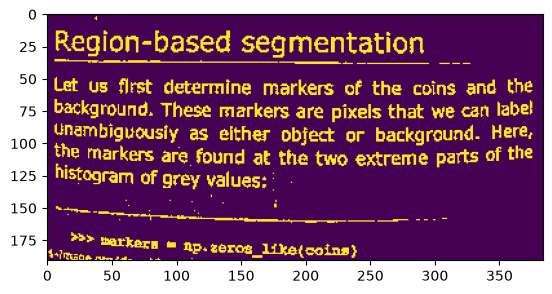

In [18]:
# Create a mask
mask_page = img_page_inverted>thresh_local
plt.imshow(mask_page)

<div align=center><img src=figures/exercise.png width=10%></div>

## Exercise: thresholding bacteria

Can you apply some of the above methods to the image loaded below?
We'll discuss in 5-10 minutes.

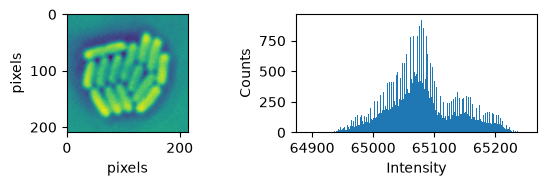

In [19]:
img_ecoli = np.invert(tiff.imread('images/microcolony_ecoli.tif'))
_, _ = plot_img_and_hist(img_ecoli)

## More advanced image processing

For the example above, and many biological images, features are not straightforward to extract.
We need more advanced methods than simple thresholding.

We'll introduce you to some advanced image processing methods, and apply them later to biological examples.

## Convolution

Convolutational image operations are at the heart of many image processing steps. You'll also see them a load in machine learning.

<img src=figures/pytorch_convolution_upscaled.jpg width=60%>

***Image source:** via [discuss.pytorch.org](https://discuss.pytorch.org/t/deformable-convolution-layer-with-variable-filter/58799).* 

In convolution, a new image of equal size is created.
The procedure goes over each pixel $(i, j)$ in the original image, and sums its neighborhood pixels multiplied with neighborhood location specific weights, 
to get the intensity value for the new pixel at location $(i ,j)$.

This allows you to manipulate the image in very useful ways.

### Examples (1)

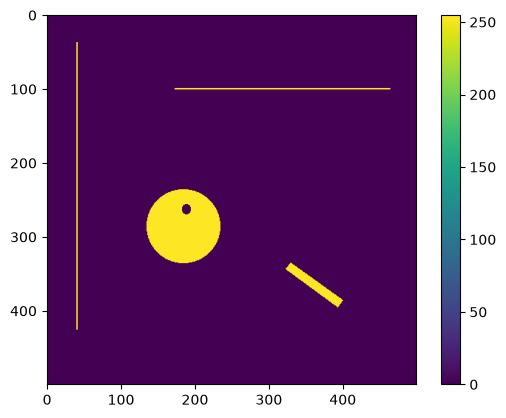

In [20]:
# Let's illustrate this concept with some examples

# Load an example picture
img_pika = tiff.imread('images/pikachu.tif')
_= plt.imshow(img_pika)
_= plt.colorbar()

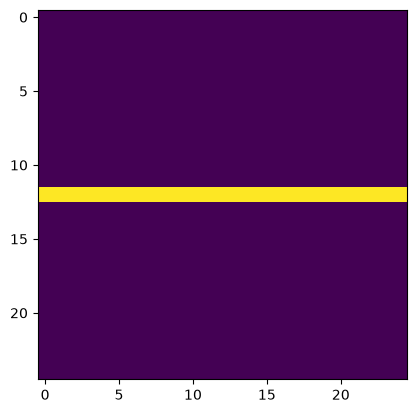

In [21]:
# Define a horizontal line "kernel"
kernel_h = np.zeros((25,25))
kernel_h[12,:] = 1
kernel_h=kernel_h/np.sum(kernel_h)
plt.imshow(kernel_h)

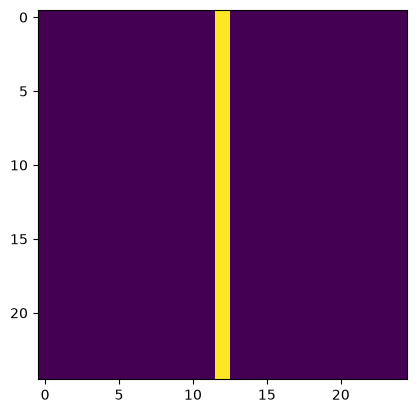

In [22]:
# Define a vertical line "kernel"
kernel_v = np.zeros((25,25))
kernel_v[:,12] = 1
kernel_v=kernel_v/np.sum(kernel_v)
plt.imshow(kernel_v)

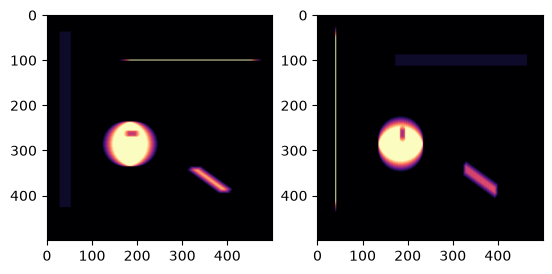

In [23]:
# Apply them both to the image
img_pika_h = ndimage.convolve(img_pika, kernel_h)
img_pika_v = ndimage.convolve(img_pika, kernel_v)

# Now show both pictures
fig, axs = plt.subplots(1,2)
axs[0].imshow(img_pika_h, cmap='magma')
axs[1].imshow(img_pika_v, cmap='magma')
plt.show()

# Can you see what happened?
    # shapes
    # intensities

Do you understand why the results looks like it does? Both how the shapes
have changed, and also how the intensities have changed?

### Examples (2)

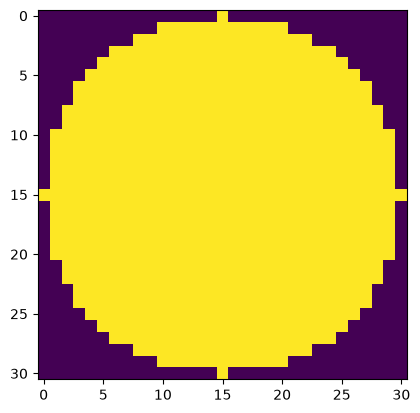

In [24]:
# Define a disk kernel
kernel_disk = sk.morphology.disk(15) 
kernel_disk = kernel_disk/np.sum(kernel_disk)
_ = plt.imshow(kernel_disk)

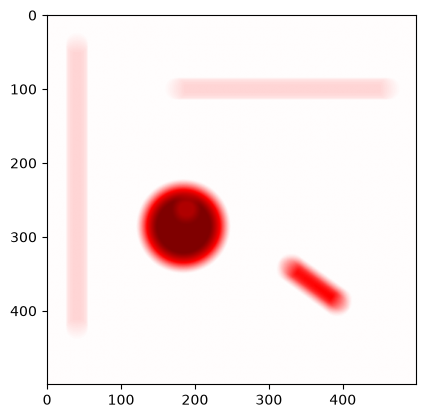

In [25]:
# Define an edge kernel
kernel_laplacian = np.array(
    [[0, -1,  0],
     [-1,  4, -1],
     [0, -1,  0]])

# Now apply and plot
img_pika_disk = ndimage.convolve(
    img_pika.astype(np.float32), 
    kernel_disk.astype(np.float32)
    )
img_pika_edge = ndimage.convolve(
    img_pika.astype(np.float32), 
    kernel_laplacian.astype(np.float32)
    )
minmaxval1 = np.max(np.abs(img_pika_disk))
_ = plt.imshow(img_pika_disk, cmap='seismic', vmin=-minmaxval1, vmax=minmaxval1)

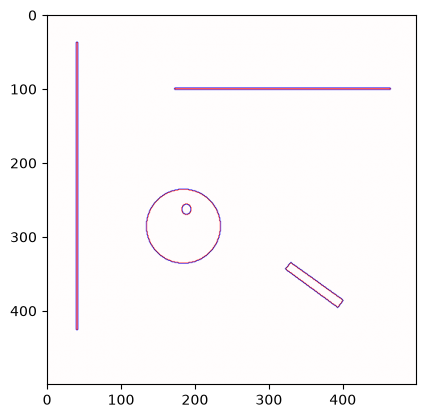

In [26]:
minmaxval2 = np.max(np.abs(img_pika_edge))
_ = plt.imshow(img_pika_edge, cmap='seismic', vmin=-minmaxval2, vmax=minmaxval2)

The seismic colormap, when centered around 0, shows positive values in red, and negative values in blue.

The first image looks blurred, and in the second image edge structures remain.

Do you understand why the 1st image is blurred?
Why edges remain in the second image are a bit more complicated. Can you take a guess as to why this is?

### The laplacian

We'll skip the math here, but the "laplacian" kernel equals a pixel's 2nd derivative. The image below illustrates why that helps to detect sudden intensity changes.

<img src=figures/plots_laplacian_1d.png width=50%>

The left panel shows an intensity change in one dimension, here $y$ would be the intensity and $x$ the location along the image.
The middle panel shows that the derivative peaks at the "edge" (note that the peak would be negative if the change goes in the other direction).
The right panel shows that around the edge, the double derivative first shows a positive peak and then a negative peak.

Thus, in the second derivative image, pixels that are near-zero and which are in the vicinity of both a negative and positive value, are close to an edge.


#### Technical note

*Both the derivative and laplacian kernel can be used to find edges.
The advantage of the Laplacian is that it better identifies the exact location
of the edge, as the zero-crossing (pixels with values close to zero) are 
precisely where the edge is. 
First-order derivatives can also be used, but they are dimension-specific (either
the derivative in the row-direction, or the derivative in the column-direction),
so the output of two convolutions needs to be combined.
Additionally, both can be sensitive to noise, why they are often combined
with a de-noising convolution (e.g. blur), as we will see below.*

## Dilation and erosion

As we'll see, it is often convenient to manipulate binary masks. 

**Morphological operations**, similar to the convolution, also construct a new picture on a pixel-by-pixel basis. They look at properties of the set of neighborhood intensity values.

The main operations are:

- **Dilation**, which takes the neighborhood maximum.
- **Erosion**, which takes the neighborhood minimum.

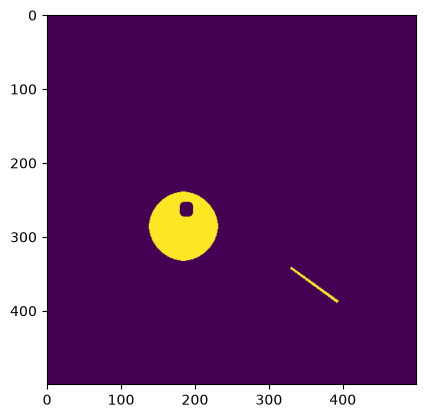

In [27]:
# Let's try
img_pika_eroded  = sk.morphology.erosion(img_pika, footprint=np.ones((7,7)))
plt.imshow(img_pika_eroded)


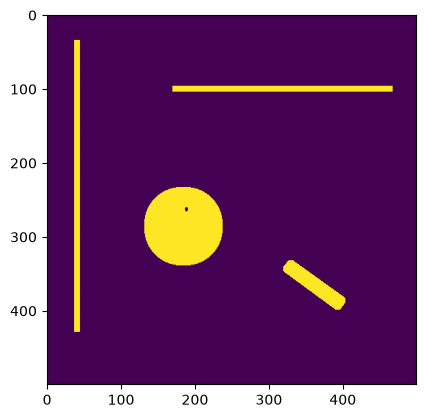

In [28]:

img_pika_dilated = sk.morphology.dilation(img_pika, footprint=np.ones((7,7)))
plt.imshow(img_pika_dilated)

### Combining operations

These operations can also be applied to grayscale images.

There exist multiple combinations of morphological operations that are often used together, such as:
- Opening (erode → dilate): removes small features, keeps coarse features.
- Closing (dilate → erode): fills small holes/gaps.
- Top-hat (image − opening): isolates small bright features (background-subtraction, spot-detection)
- Morphological gradient (dilation − erosion): edges.

<div align=center><img src=figures/exercise.png width=10%></div>

## Exercise: Apply opening and closing

- Apply `sk.morphology.closing` and `sk.morphology.opening` to the "pikachu" image. Do you understand the result?
- Use the argument `footprint=sk.morphology.disk(7)`. Does this change the outcome? Why?

We'll discuss in 5-10 minutes. 


## Built-in filtering and edge detection

With the above tools, we could make custom functions that perform edge detection or blurring.

There are however also some optimized built-in functions that perform these tasks.

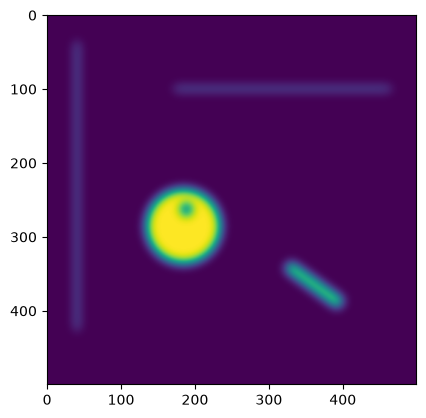

In [29]:
# Blurring using a Gaussian kernel
img_pika_gauss07 = sk.filters.gaussian(img_pika, sigma=7)
_ = plt.imshow(img_pika_gauss07)


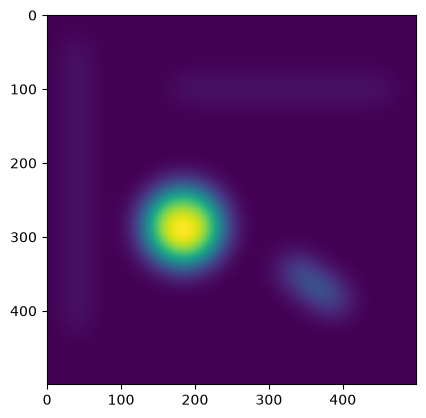

In [30]:
# Stronger blur
img_pika_gauss20 = sk.filters.gaussian(img_pika, sigma=20)
_ = plt.imshow(img_pika_gauss20)

### Edge detection methods

There exist multiple built-in edge detection methods, 
common ones include: `sk.filters.sobel()`, `sk.filters.prewitt()`, `sk.filters.laplace()`, `sk.feature.canny()`. See also the [documentation](https://scikit-image.org/docs/stable/api/skimage.filters.html).

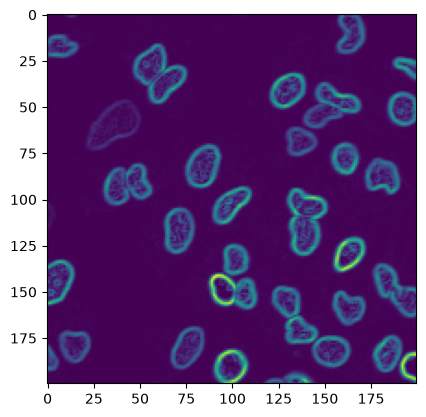

In [31]:
# Let's try Sobel on the nuclei
img_edges = sk.filters.sobel(img_nuclei)
_ = plt.imshow(img_edges[0:200,0:200]) # e.g. threshold > 0.01, or use local threshold?

### Neighborhood-based filtering

Neighborhood-based filtering methods include `ndimage.minimum_filter()`, `ndimage.maximum_filter`, `ndimage.median_filter()`.

The median filter is for example relevant to remove noise from images.

(<Figure size 590.551x196.85 with 2 Axes>,
 array([<Axes: xlabel='pixels', ylabel='pixels'>,
        <Axes: xlabel='Intensity', ylabel='Counts'>], dtype=object))

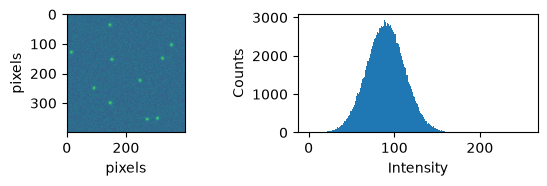

In [32]:
img_noisy = tiff.imread("images/spots.tif")
plot_img_and_hist(img_noisy)

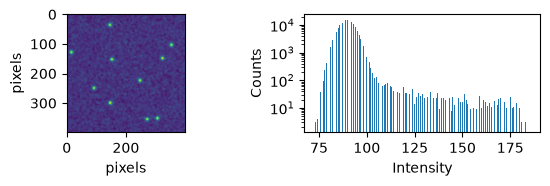

In [33]:
img_noisy_median = ndimage.median_filter(img_noisy, footprint=sk.morphology.disk(4))
fig, axs = plot_img_and_hist(img_noisy_median)
axs[1].set_yscale("log")

<div align=center><img src=figures/exercise.png width=10%></div>

### Exercise: thresholding

- Can you create a binary mask for the points in `img_noisy`?
- Can you create a binary mask that contains the edges of `img_nuclei`?

##### Optional help: hints for the nuclear edges

One solution involves using a combination of `erosion()`, the original `nuclei_mask`, and combining different masks using `np.logical_..()` ([documentation](https://numpy.org/doc/stable/reference/routines.logic.html#logical-operations)).

If you want a polished result, perhaps you can also throw in an `opening()` operation.